In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [5]:
sales = pd.read_csv("sales_data.csv")
customers = pd.read_csv("customer_churn.csv")

In [6]:
print("Sales Data")
display(sales.head())

print("Customer Data")
display(customers.head())

Sales Data


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


Customer Data


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [7]:
sales.info()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   P

In [8]:
print(sales.isnull().sum())
print(customers.isnull().sum())

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


In [10]:
sales["Date"] = pd.to_datetime(sales["Date"])
sales["Year"] = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month
sales["Day"] = sales["Date"].dt.day

In [11]:
total_revenue = sales["Total_Sales"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 12365048


In [12]:
total_customers = sales["Customer_ID"].nunique()
print("Total Customers:", total_customers)

Total Customers: 100


In [13]:
average_order_value = sales["Total_Sales"].mean()
print("Average Order Value:", average_order_value)

Average Order Value: 123650.48


In [14]:
monthly_sales = sales.groupby("Month")["Total_Sales"].sum()

print(monthly_sales)

Month
1    4120524
2    2656050
3    4485006
4    1103468
Name: Total_Sales, dtype: int64


In [15]:
region_sales = sales.groupby("Region")["Total_Sales"].sum()

print(region_sales)

Region
East     2519639
North    3983635
South    3737852
West     2123922
Name: Total_Sales, dtype: int64


In [16]:
best_products = sales.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

print(best_products)

Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64


In [17]:
top_customers = sales.groupby("Customer_ID")["Total_Sales"].sum().sort_values(ascending=False).head(10)

print(top_customers)

Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
CUST084    324144
CUST070    318762
CUST005    318680
CUST065    312564
CUST028    304465
Name: Total_Sales, dtype: int64


In [18]:
pivot_table = pd.pivot_table(
    sales,
    values="Total_Sales",
    index="Region",
    columns="Product",
    aggfunc="sum"
)

display(pivot_table)

Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


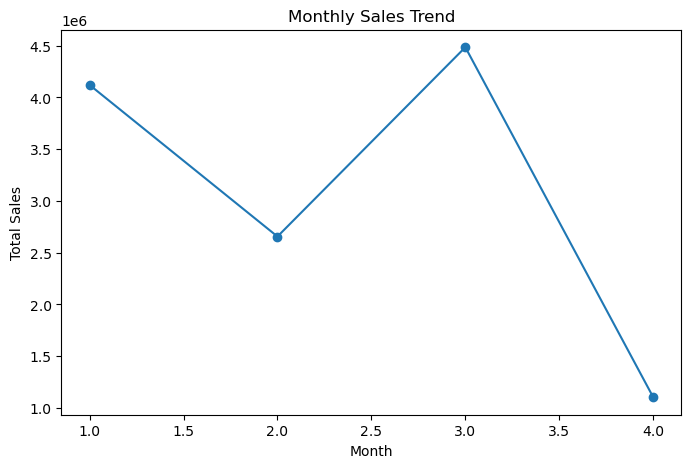

In [19]:
plt.figure(figsize=(8,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

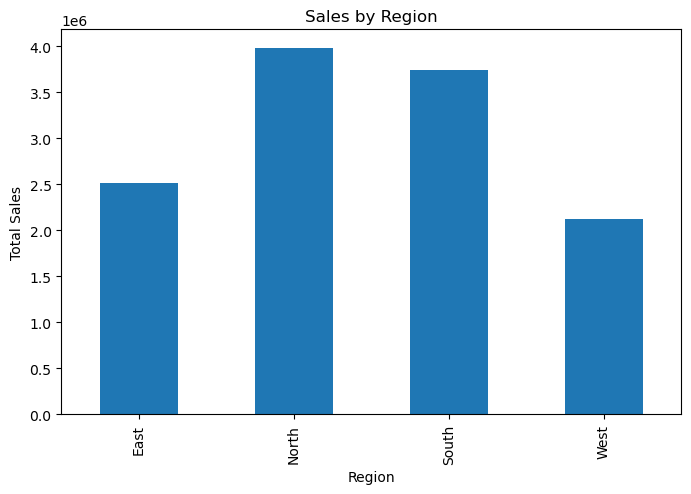

In [20]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

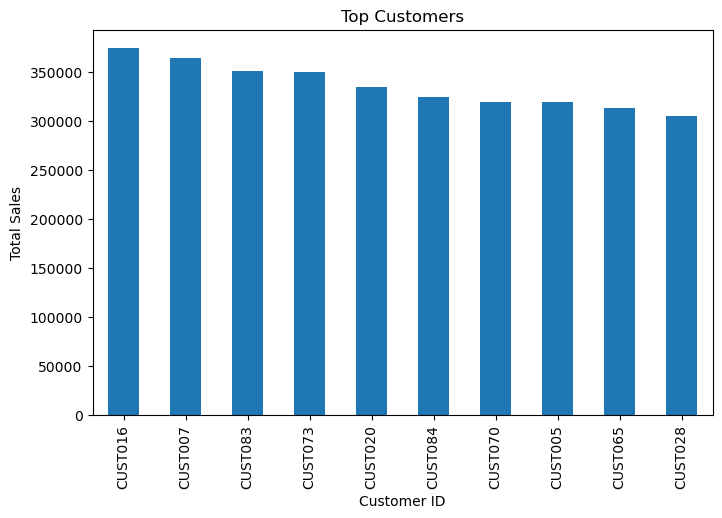

In [21]:
plt.figure(figsize=(8,5))

top_customers.plot(kind="bar")

plt.title("Top Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")

plt.show()

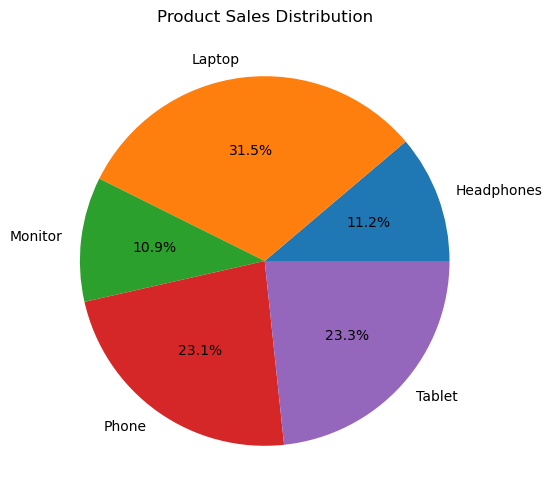

In [22]:
product_sales = sales.groupby("Product")["Total_Sales"].sum()

plt.figure(figsize=(6,6))

product_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Product Sales Distribution")

plt.ylabel("")

plt.show()

In [23]:
print("CUSTOMER SALES ANALYSIS REPORT")

print("Total Revenue:", total_revenue)
print("Total Customers:", total_customers)
print("Average Order Value:", average_order_value)

print("\nTop Customer:")
print(top_customers.head(1))

CUSTOMER SALES ANALYSIS REPORT
Total Revenue: 12365048
Total Customers: 100
Average Order Value: 123650.48

Top Customer:
Customer_ID
CUST016    373932
Name: Total_Sales, dtype: int64
